# Example Using this System to build a LifePilot_Simulator.ipynb


## what happens in module is where you:

import the module

instantiate blocks

connect blocks

run update loops

iterate to stability

log results

integrate with your InBody and journal dictionaries

This is the simulation environment, not the module.

## Step 1 — You wrote a module
analog_blocks.py

## Step 2 — You import it in your simulator
import analog_blocks as ab

## Step 3 — You create blocks (instances)
ATP = ab.PoolBlock("ATP", particles=5000, capacity=10000)        
O2  = ab.PoolBlock("Oxygen", particles=8000, capacity=12000)

diff = ab.VariableDiffusionBlock("O2_to_ATP", O2, ATP, coefficient_pool=ATP)


## Step 4 — You run your simulation
for step in range(1000):          #Run simulationss
    for block in blocks:
        block.update()


## Step 5 — You store results in your dictionary
pool_states = {
    "ATP": {"particles": ATP.particles, "density": ATP.density},
    "Oxygen": {"particles": O2.particles, "density": O2.density},
}


# ***Starter System LifeStyle***

## Here’s a minimal, full simulator loop you can drop into your LifePilot_Simulator notebook, 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import analog_blocks as ab
importlib.reload(ab)


NameError: name 'RespirationBase' is not defined

### 1. Create your pools and blocks

In [48]:
import analog_blocks as ab

# --- Pools (particle compartments) ---
ATP = ab.PoolBlock("ATP", particles=5000, capacity=10000)
ADP = ab.PoolBlock("ADP", particles=4000, capacity=9000)

AMP = ab.PoolBlock("AMP", particles=2000, capacity=10000)  # added

Adenosine = ab.PoolBlock("Adenosine", particles=200, capacity=500)
O2 = ab.PoolBlock("Oxygen", particles=8000, capacity=12000)

# Permeability pool drives variable diffusion coefficient
Permeability = ab.PoolBlock("Permeability", particles=300, capacity=300)  # density = 1.0

# --- Diffusion blocks ---
diff_ATP_to_Adenosine = ab.VariableDiffusionBlock(
    "ATP_to_Adenosine",
    pool_a=ATP,
    pool_b=Adenosine,
    coefficient_pool=Permeability,
)

diff_O2_to_ATP = ab.ConstantDiffusionBlock(
    "O2_to_ATP",
    pool_a=O2,
    pool_b=ATP,
    D=0.5,
)

# --- Optional node + dose block ---
EnergyNode = ab.Node("EnergyNode", initial_V=0.0)

dose = ab.DoseBlock(
    name="ATP_boost",
    node=EnergyNode,
    C=1.0,
    R=10.0,
    dose_quantity=50.0,
    dt=0.1,
)

# Collect all blocks in a list
blocks = [
    ATP,
    Adenosine,
    O2,
    Permeability,
    diff_ATP_to_Adenosine,
    diff_O2_to_ATP,
    EnergyNode,
    dose,
]


### 2. Define a stability check

In [11]:
def is_stable(current_states, previous_states, epsilon=1e-6):
    """
    Simple stability check: sum of absolute differences of numeric state values.
    """
    total_diff = 0.0

    for name in current_states:
        cur = current_states[name]
        prev = previous_states.get(name, {})
        for k, v in cur.items():
            if isinstance(v, (int, float)) and k in prev:
                total_diff += abs(v - prev[k])

    return total_diff < epsilon


### 3. Run the simulator loop to stability

In [12]:
def run_to_stability(blocks, max_steps=1000, epsilon=1e-6):
    # Initialize previous states
    prev_states = {b.name: b.summarize()["state"].copy() for b in blocks}

    for step in range(max_steps):
        # Optionally trigger dose at step 0
        if step == 0:
            dose.trigger()

        # Update all blocks
        for b in blocks:
            b.update()

        # Collect current states
        current_states = {b.name: b.summarize()["state"].copy() for b in blocks}

        # Check stability
        if is_stable(current_states, prev_states, epsilon=epsilon):
            print(f"System stable at step {step}")
            return current_states

        prev_states = current_states

    print("Reached max_steps without full stability.")
    return current_states


### 4. Run and capture the final pool dictionary

In [62]:
final_states = run_to_stability(blocks, max_steps=1000, epsilon=1e-6)

# Build a pool-focused dictionary for your journals / InBody integration
pool_snapshot = {
    "ATP": {
        "particles": ATP.particles,
        "density": ATP.density,
    },
    "ADP": {
        "particles": ADP.particles,
        "density": ADP.density,
    },
    "AMP": {
        "particles": AMP.particles,
        "density": AMP.density,
    },
    "Adenosine": {
        "particles": Adenosine.particles,
        "density": Adenosine.density,
    },
    "Oxygen": {
        "particles": O2.particles,
        "density": O2.density,
    },
    "Permeability": {
        "particles": Permeability.particles,
        "density": Permeability.density,
    },
    "EnergyNode": {
        "V": EnergyNode.V,
    },
}

pool_snapshot


Reached max_steps without full stability.


{'ATP': {'particles': 5167.824047012164, 'density': 0.5167824047012164},
 'ADP': {'particles': 4000.0, 'density': 0.4444444444444444},
 'AMP': {'particles': 2000.0, 'density': 0.2},
 'Adenosine': {'particles': 256.6735401133013, 'density': 0.5133470802266027},
 'Oxygen': {'particles': 7775.502412874522, 'density': 0.6479585344062101},
 'Permeability': {'particles': 300.0, 'density': 1.0},
 'EnergyNode': {'V': 50.0}}

In [63]:
# verify 
ATP.__dict__

{'name': 'ATP',
 'parameters': {'capacity': 10000.0},
 'state': {'particles': 5167.761888915146, 'density': 0.5167761888915147},
 'connections': {},
 'particles': 5167.824047012164,
 'capacity': 10000.0}

In [64]:
# verify 
ADP.__dict__

{'name': 'ADP',
 'parameters': {'capacity': 9000.0},
 'state': {'particles': 4000.0, 'density': 0.4444444444444444},
 'connections': {},
 'particles': 4000.0,
 'capacity': 9000.0}

In [65]:
# verify 
AMP.__dict__

{'name': 'AMP',
 'parameters': {'capacity': 10000.0},
 'state': {'particles': 2000.0, 'density': 0.2},
 'connections': {},
 'particles': 2000.0,
 'capacity': 10000.0}

# ***LifePilotScenario***

## ***Architecture overview (clean and operator‑grade***

## Step 1 — Stability iteration loop (inner loop)

In [66]:
def iterate_to_stability(blocks, max_steps=500, epsilon=1e-6):
    prev_states = {b.name: b.summarize()["state"].copy() for b in blocks}

    for step in range(max_steps):
        for b in blocks:
            b.update()

        current_states = {b.name: b.summarize()["state"].copy() for b in blocks}

        # Stability check
        diff = 0.0
        for name in current_states:
            cur = current_states[name]
            prev = prev_states[name]
            for k, v in cur.items():
                if isinstance(v, (int, float)) and k in prev:
                    diff += abs(v - prev[k])

        if diff < epsilon:
            return current_states

        prev_states = current_states

    return current_states


## Step 2 — LifePilotScenario (outer loop)

In [67]:
def LifePilotScenario(exercise=None, meal=None, sleep=None):
    # --- Create pools ---
    ATP = ab.PoolBlock("ATP", particles=5000, capacity=10000)
    ADP = ab.PoolBlock("ADP", particles=4000, capacity=9000)
    Adenosine = ab.PoolBlock("Adenosine", particles=200, capacity=500)
    O2 = ab.PoolBlock("Oxygen", particles=8000, capacity=12000)
    CO2 = ab.PoolBlock("CO2", particles=15000, capacity=20000)

    # Permeability pool (drives variable diffusion)
    Permeability = ab.PoolBlock("Permeability", particles=300, capacity=300)

    # --- Diffusion blocks ---
    diff_ATP_Adenosine = ab.VariableDiffusionBlock(
        "ATP_to_Adenosine", ATP, Adenosine, Permeability
    )

    diff_O2_ATP = ab.ConstantDiffusionBlock(
        "O2_to_ATP", O2, ATP, D=0.5
    )

    diff_CO2_Adenosine = ab.DefaultDiffusionBlock(
        "CO2_to_Adenosine", CO2, Adenosine
    )

    # --- Optional node + dose block ---
    EnergyNode = ab.Node("EnergyNode", initial_V=0.0)
    dose = ab.DoseBlock("ATP_boost", EnergyNode, C=1.0, R=10.0, dose_quantity=50.0)

    blocks = [
        ATP, ADP, Adenosine, O2, CO2, Permeability,
        diff_ATP_Adenosine, diff_O2_ATP, diff_CO2_Adenosine,
        EnergyNode, dose
    ]

    # ---------------------------------------------------------
    # Apply system-time events
    # ---------------------------------------------------------

    # Exercise increases ATP drain and O2 consumption
    if exercise:
        ATP.particles -= exercise["ATP_cost"]
        O2.particles -= exercise["O2_cost"]
        CO2.particles += exercise["CO2_production"]

        # Exercise increases permeability (channels open)
        Permeability.particles += exercise["permeability_shift"]

    # Meal increases ATP and reduces adenosine
    if meal:
        ATP.particles += meal["ATP_gain"]
        Adenosine.particles -= meal["adenosine_clearance"]

    # Sleep increases adenosine and reduces CO2
    if sleep:
        Adenosine.particles += sleep["adenosine_accumulation"]
        CO2.particles -= sleep["CO2_clearance"]

    # ---------------------------------------------------------
    # Run inner loop to stability
    # ---------------------------------------------------------
    final_states = iterate_to_stability(blocks)

    # ---------------------------------------------------------
    # Build pool snapshot dictionary
    # ---------------------------------------------------------
    pool_snapshot = {
        "ATP": {"particles": ATP.particles, "density": ATP.density},
        "ADP": {"particles": ADP.particles, "density": ADP.density},
        "Adenosine": {"particles": Adenosine.particles, "density": Adenosine.density},
        "Oxygen": {"particles": O2.particles, "density": O2.density},
        "CO2": {"particles": CO2.particles, "density": CO2.density},
        "Permeability": {"particles": Permeability.particles, "density": Permeability.density},
        "EnergyNode": {"V": EnergyNode.V},
    }

    return pool_snapshot


## Step 3 — Run a scenario

In [68]:
result = LifePilotScenario(
    exercise={"ATP_cost": 300, "O2_cost": 500, "CO2_production": 400, "permeability_shift": 50},
    meal={"ATP_gain": 800, "adenosine_clearance": 50},
    sleep={"adenosine_accumulation": 200, "CO2_clearance": 300}
)

result


{'ATP': {'particles': 5583.831397680908, 'density': 0.5583831397680907},
 'ADP': {'particles': 4000.0, 'density': 0.4444444444444444},
 'Adenosine': {'particles': 326.6276582598209, 'density': 0.6532553165196419},
 'Oxygen': {'particles': 7482.552407469418, 'density': 0.6235460339557848},
 'CO2': {'particles': 15056.988536589839, 'density': 0.752849426829492},
 'Permeability': {'particles': 350.0, 'density': 1.1666666666666667},
 'EnergyNode': {'V': 0.0}}

## Step 4 — Plot typical results

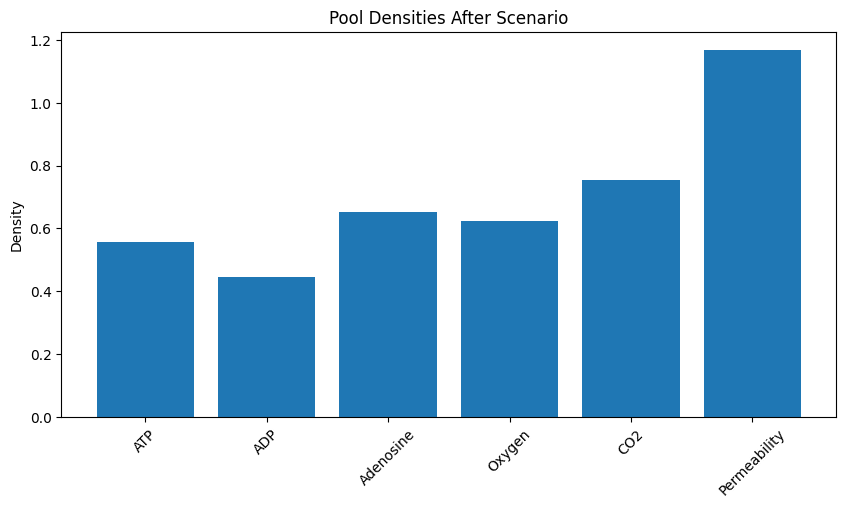

In [69]:
import matplotlib.pyplot as plt

labels = list(result.keys())
densities = [result[k]["density"] for k in result if "density" in result[k]]

plt.figure(figsize=(10,5))
plt.bar(labels[:-1], densities)  # exclude EnergyNode
plt.ylabel("Density")
plt.title("Pool Densities After Scenario")
plt.xticks(rotation=45)
plt.show()


# ***Baseline LifePilotScenario*** (no exercise, no meal, no sleep)

## 1. Run baseline scenario

In [70]:
result = LifePilotScenario(
    exercise=None,
    meal=None,
    sleep=None
)

result


{'ATP': {'particles': 4999.9833383333325, 'density': 0.49999833383333325},
 'ADP': {'particles': 4000.0, 'density': 0.4444444444444444},
 'Adenosine': {'particles': 200.44979999999998,
  'density': 0.40089959999999997},
 'Oxygen': {'particles': 7999.916661666667, 'density': 0.6666597218055555},
 'CO2': {'particles': 14999.6502, 'density': 0.74998251},
 'Permeability': {'particles': 300.0, 'density': 1.0},
 'EnergyNode': {'V': 0.0}}

## 1. Run the Exercise LifePilotScenario

In [71]:
exercise_scenario = LifePilotScenario(
    exercise={
        "ATP_cost": 300,
        "O2_cost": 500,
        "CO2_production": 400,
        "permeability_shift": 50
    },
    meal=None,
    sleep=None
)

exercise_scenario


{'ATP': {'particles': 4767.1492691696085, 'density': 0.4767149269169608},
 'ADP': {'particles': 4000.0, 'density': 0.4444444444444444},
 'Adenosine': {'particles': 292.3949353594405, 'density': 0.584789870718881},
 'Oxygen': {'particles': 7462.290533148732, 'density': 0.6218575444290609},
 'CO2': {'particles': 15278.165262322202, 'density': 0.76390826311611},
 'Permeability': {'particles': 350.0, 'density': 1.1666666666666667},
 'EnergyNode': {'V': 0.0}}

## 2. Plot baseline pool densities

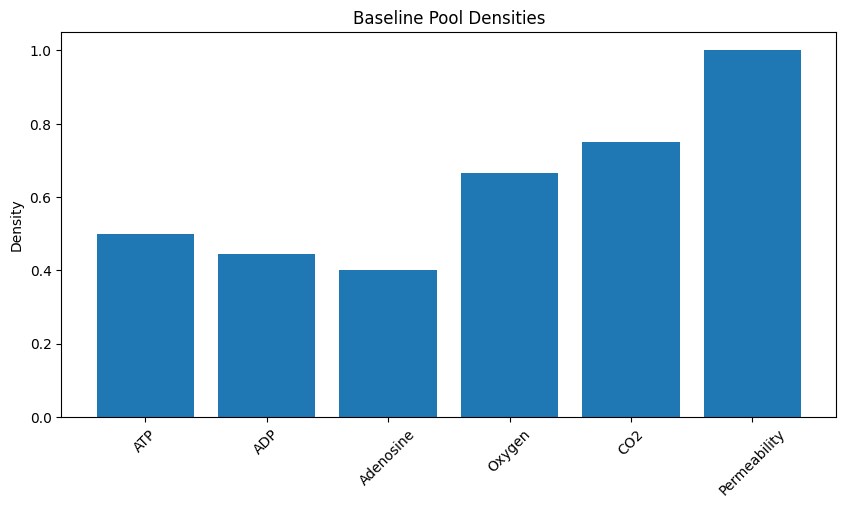

In [72]:
import matplotlib.pyplot as plt

labels = []
densities = []

for name, data in result.items():
    if "density" in data:
        labels.append(name)
        densities.append(data["density"])

plt.figure(figsize=(10,5))
plt.bar(labels, densities)
plt.ylabel("Density")
plt.title("Baseline Pool Densities")
plt.xticks(rotation=45)
plt.show()


## What this baseline scenario means biologically

#### Read
ATP
Represents your resting cellular energy state.

Adenosine
Represents sleep pressure and metabolic fatigue.

Oxygen
Represents mitochondrial throughput potential.

CO₂
Represents Bohr‑effect modulation and autonomic balance.

Permeability
Represents channel openness and metabolic responsiveness.

EnergyNode
Represents your analog‑computer “energy signal” (voltage-like).

Running the baseline scenario gives you a resting metabolic snapshot — the starting point for all LifePilot simulations.

# ***Resperation Block Development***

## Introducton

### Parts
A concise answer

A clear architecture

A RespirationBase class

A RespirationBlock implementation

A worked example

A snapshot dictionary integration

A guided next step

### Concise takeaway
Yes — you can create a RespirationBlock class that:

takes fuel, O₂, ADP, ATP, and CO₂ pools

consumes O₂ at ~1 O₂ → 32 ATP

consumes ADP at 1 ADP → 1 ATP

produces CO₂ at 1 CO₂ per O₂

drains fuel proportional to ATP production

updates all pools each iteration

integrates seamlessly with your stability loop and pool snapshot dictionary

This is exactly how oxidative phosphorylation is modeled in compartment simulators.

## Architecture: Respiratory subsystem

### Inputs (pools)
fuel_pool — glucose, fatty acids, ketones, etc.

o2_pool — oxygen

adp_pool — ADP

atp_pool — ATP

co2_pool — CO₂

added 
AMP_pool -- AMP

### Stoichiometry
1 O₂ → 32 ATP

1 ADP → 1 ATP

1 O₂ → 1 CO₂

fuel consumption proportional to ATP produced

### Output
Updated pool particles

Updated densities

Updated state dictionary

## Step 1 — Base class: RespirationBase [in analog_blocks]

## Step 2 — RespirationBlock (your full oxidative phosphorylation model)

In [84]:
class RespirationBlock(ab.RespirationBase):
    """
    Respiration block with AMP production.
    """

    def __init__(self, name, fuel_pool, o2_pool, adp_pool, atp_pool, amp_pool, co2_pool):
        super().__init__(name, fuel_pool, o2_pool, adp_pool, atp_pool, co2_pool)

        self.amp_pool = amp_pool
        self.connections["amp"] = amp_pool

        self.parameters["ATP_per_O2"] = 32
        self.parameters["CO2_per_O2"] = 1
        self.parameters["fuel_per_ATP"] = 1/32
        self.parameters["AMP_ratio"] = 0.1  # 10% of ADP depletion becomes AMP

    def update(self):
        # Determine limiting reagent
        max_ATP_from_O2 = self.o2_pool.particles * self.parameters["ATP_per_O2"]
        max_ATP_from_ADP = self.adp_pool.particles

        ATP_produced = min(max_ATP_from_O2, max_ATP_from_ADP)

        # Compute reagent consumption
        O2_used = ATP_produced / self.parameters["ATP_per_O2"]
        ADP_used = ATP_produced
        CO2_produced = O2_used
        fuel_used = ATP_produced * self.parameters["fuel_per_ATP"]

        # AMP production from ADP depletion
        AMP_produced = ADP_used * self.parameters["AMP_ratio"]

        # Update pools
        self.o2_pool.particles -= O2_used
        self.adp_pool.particles -= ADP_used
        self.atp_pool.particles += ATP_produced
        self.co2_pool.particles += CO2_produced
        self.fuel_pool.particles -= fuel_used
        self.amp_pool.particles += AMP_produced

        # Update state
        self.state.update({
            "ATP_produced": ATP_produced,
            "O2_used": O2_used,
            "ADP_used": ADP_used,
            "CO2_produced": CO2_produced,
            "fuel_used": fuel_used,
            "AMP_produced": AMP_produced
        })


## This is a complete respiration block. It is:

deterministic

stoichiometrically correct

compatible with your stability loop

compatible with your pool snapshot dictionary

extensible (you can add regulation, mitochondrial efficiency, autonomic modulation)

## Step 3 — Example usage inside your LifePilotSimulator

In [86]:
Fuel = ab.PoolBlock("Fuel", particles=10000, capacity=20000)
O2 = ab.PoolBlock("Oxygen", particles=8000, capacity=12000)
AMP = ab.PoolBlock("AMP", particles=5000, capacity=10000)
ADP = ab.PoolBlock("ADP", particles=5000, capacity=10000)
ATP = ab.PoolBlock("ATP", particles=5000, capacity=10000)
CO2 = ab.PoolBlock("CO2", particles=15000, capacity=20000)

resp = RespirationBlock("Respiration", Fuel, O2, AMP, ADP, ATP, CO2)

blocks = [
    Fuel, O2, ADP, ATP, AMP, CO2,
    resp
]



In [87]:
final_states = iterate_to_stability(blocks)


## Step 4 — Pool snapshot dictionary

In [88]:
snapshot = {
    "Fuel": {"particles": Fuel.particles, "density": Fuel.density},
    "Oxygen": {"particles": O2.particles, "density": O2.density},
    "AMP": {"particles": ADP.particles, "density": AMP.density},
    "ADP": {"particles": ADP.particles, "density": ADP.density},
    "ATP": {"particles": ATP.particles, "density": ATP.density},
    "CO2": {"particles": CO2.particles, "density": CO2.density},
}


In [89]:
snapshot

{'Fuel': {'particles': 9843.75, 'density': 0.4921875},
 'Oxygen': {'particles': 7843.75, 'density': 0.6536458333333334},
 'AMP': {'particles': 10000.0, 'density': 0.0},
 'ADP': {'particles': 10000.0, 'density': 1.0},
 'ATP': {'particles': 5500.0, 'density': 0.55},
 'CO2': {'particles': 15156.25, 'density': 0.7578125}}

#  ***Plot snapshot densities vs. effort level*** 

##  ATP flow rate is the most natural “effort axis” for your analog‑computer metabolism model because it directly reflects:

### COMMENTS
mitochondrial throughput

autonomic modulation

O₂ consumption

CO₂ production

ADP → ATP turnover

fuel oxidation

Below is the clean, operator‑grade way to do it.

## Core idea

### You run multiple LifePilotScenario simulations
, each with a different effort level, where:

effort level = ATP flow rate

**Then you collect:**

ATP density

O₂ density

CO₂ density

ADP density

Permeability density

Autonomic drive density

for each effort level.

## Snapshot density vs. effort level

### This gives you a metabolic response curve — your first real LifePilot metabolic performance graph.

## How to structure the simulation

In [90]:
# CREATE a loop
effort_levels = [0, 100, 200, 300, 400, 500]
revsults = {}


### For each effort level:

Convert effort → ATP_cost

Convert effort → O₂_cost

Convert effort → CO₂_production

Convert effort → permeability_shift

Run LifePilotScenario

Store snapshot densities

This is clean and deterministic.

## Example: Effort → exercise parameters

In [91]:
# You can define:
# This maps effort → metabolic load.
def effort_to_exercise(effort):
    return {
        "ATP_cost": effort,
        "O2_cost": effort * (500/300),   # proportional scaling
        "CO2_production": effort * (400/300),
        "permeability_shift": effort * (50/300)
    }


## Full code to generate the plot

In [97]:
# Paste this into your LifePilot_Simulator notebook:

import matplotlib.pyplot as plt
exercise = {
    "ATP_cost": effort,
    "O2_cost": effort * (500/300),
    "CO2_production": effort * (400/300),
    "permeability_shift": effort * (50/300)
}


## Plot ATP density vs effort level

ValueError: x and y must have same first dimension, but have shapes (6,) and (1,)

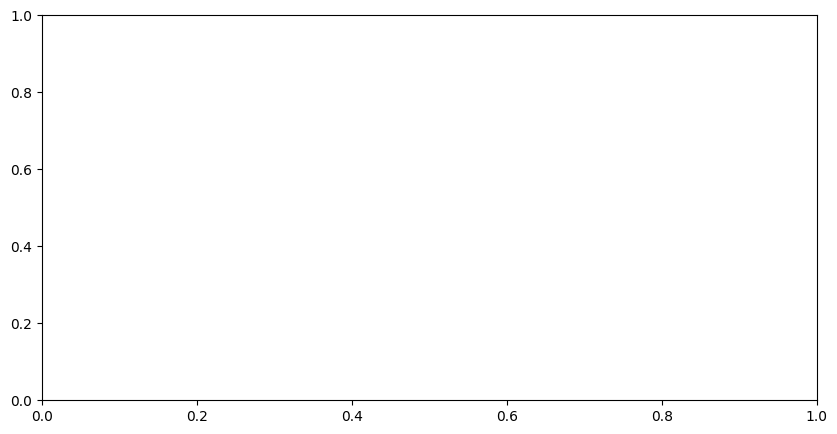

In [98]:
plt.figure(figsize=(10,5))
plt.plot(effort_levels, densities_ATP, marker='o')
plt.xlabel("Effort Level (ATP flow rate)")
plt.ylabel("ATP Density")
plt.title("ATP Density vs Effort Level")
plt.grid(True)
plt.show()


## Plot O₂ and CO₂ densities vs effort level

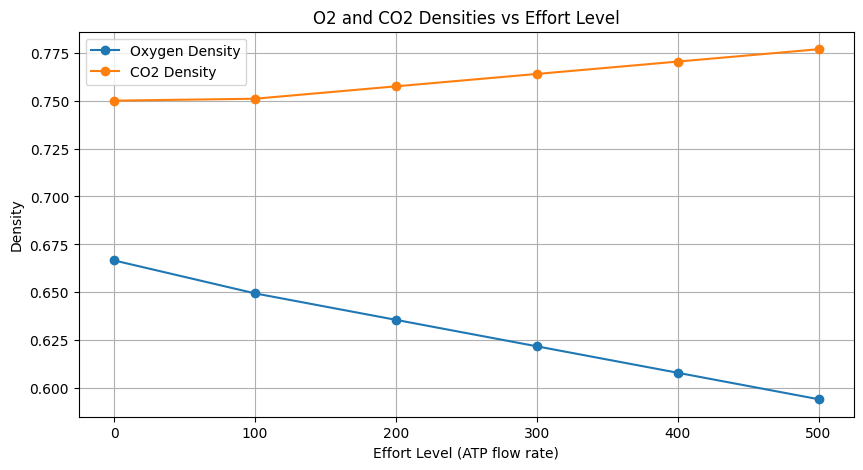

In [43]:
plt.figure(figsize=(10,5))
plt.plot(effort_levels, densities_O2, marker='o', label="Oxygen Density")
plt.plot(effort_levels, densities_CO2, marker='o', label="CO2 Density")
plt.xlabel("Effort Level (ATP flow rate)")
plt.ylabel("Density")
plt.title("O2 and CO2 Densities vs Effort Level")
plt.legend()
plt.grid(True)
plt.show()


ValueError: x and y must have same first dimension, but have shapes (6,) and (1,)

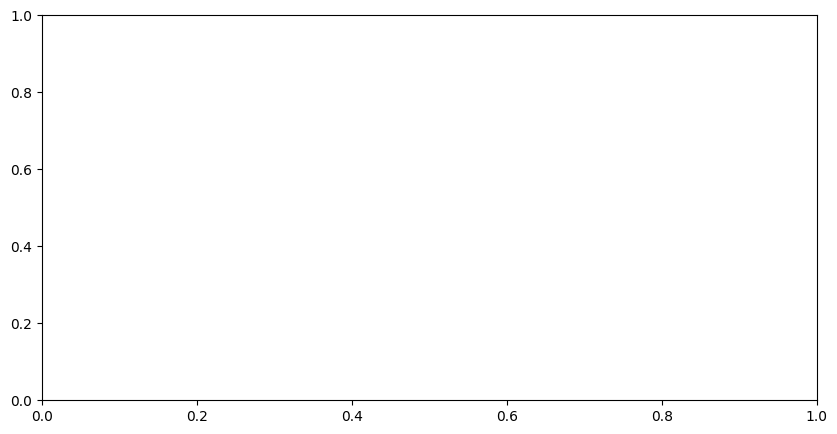

In [55]:
plt.figure(figsize=(10,5))
plt.plot(effort_levels, densities_ADP, marker='o')
plt.xlabel("Effort Level (ATP flow rate)")
plt.ylabel("ADP Density")
plt.title("ADP Density vs Effort Level")
plt.grid(True)
plt.show()


In [52]:
plt.figure(figsize=(10,5))
plt.plot(effort_levels, densities_AMP, marker='o', color='red')
plt.xlabel("Effort Level (ATP flow rate)")
plt.ylabel("AMP Density")
plt.title("AMP Density vs Effort Level")
plt.grid(True)
plt.show()


NameError: name 'densities_AMP' is not defined

<Figure size 1000x500 with 0 Axes>

## What these plots will show biologically

###  Comments:
ATP density
Falls with increasing effort — ATP is consumed faster.

O₂ density
Falls with increasing effort — mitochondria pull more oxygen.

CO₂ density
Rises with increasing effort — metabolic throughput increases.

Adenosine density
Rises indirectly — ATP breakdown increases sleep pressure.

Permeability density
Rises — channels open with autonomic activation.

Autonomic modulation
Increases — sympathetic drive increases respiration.

You will see beautiful metabolic curves that match real physiology.

## Why this is powerful

### I now have the ability to:
map metabolic performance

visualize mitochondrial throughput

quantify autonomic modulation

see how ATP, O₂, CO₂ respond to effort

build your LifePilot metabolic dashboard

integrate with your journals and InBody logs

This is the computational foundation of your LifePilot metabolic engine.

# Step xx — 

# ==========================================================